# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION
**Convolutional Neural Networks: Custom Implementation vs Transfer Learning**

---

**STUDENT INFORMATION**

| Field | Value |
|-------|-------|
| BITS ID | `2025ae05144` |
| Name | `Shubham Pardeshi` |
| Email | `2025ae05144@wilp.bits-pilani.ac.in` |
| Date | `` |

In [7]:
# ============================================================
# INSTALL DEPENDENCIES (Kaggle may not have all packages)
# ============================================================
!pip install -q tensorflow keras scikit-learn matplotlib seaborn pandas numpy pillow opencv-python-headless

In [8]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import zipfile
import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from PIL import Image
import cv2

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [9]:
# ============================================================
# PART 1: DATASET LOADING
# ============================================================
# Microsoft Cats vs Dogs dataset - downloaded from public URL
# Original: https://www.microsoft.com/en-us/download/details.aspx?id=54765

import zipfile

DATASET_URL = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

print("Downloading Cats vs Dogs dataset from Microsoft...")
zip_path = tf.keras.utils.get_file(
    "catsvsdogs.zip",
    origin=DATASET_URL,
    extract=True
)

# Find the extracted PetImages directory
extract_dir = os.path.dirname(zip_path)
PET_DIR = None
for candidate in [
    os.path.join(extract_dir, "PetImages"),
    os.path.join(extract_dir, "kagglecatsanddogs_5340", "PetImages"),
]:
    if os.path.isdir(candidate):
        PET_DIR = candidate
        break

# Fallback: search recursively
if PET_DIR is None:
    for root, dirs, _ in os.walk(extract_dir):
        if "PetImages" in dirs:
            PET_DIR = os.path.join(root, "PetImages")
            break

assert PET_DIR is not None, f"Could not find PetImages/ in {extract_dir}"

CAT_DIR = os.path.join(PET_DIR, "Cat")
DOG_DIR = os.path.join(PET_DIR, "Dog")

print(f"Cat directory: {CAT_DIR}")
print(f"Dog directory: {DOG_DIR}")

# List all image files
cat_files = sorted(glob.glob(os.path.join(CAT_DIR, "*.jpg")))
dog_files = sorted(glob.glob(os.path.join(DOG_DIR, "*.jpg")))
cat_files += sorted(glob.glob(os.path.join(CAT_DIR, "*.png")))
cat_files += sorted(glob.glob(os.path.join(CAT_DIR, "*.jpeg")))
dog_files += sorted(glob.glob(os.path.join(DOG_DIR, "*.png")))
dog_files += sorted(glob.glob(os.path.join(DOG_DIR, "*.jpeg")))

print(f"\nCat images: {len(cat_files)}")
print(f"Dog images: {len(dog_files)}")
print(f"Total: {len(cat_files) + len(dog_files)}")


Cat directory: /root/.keras/datasets/catsvsdogs_extracted/PetImages/Cat
Dog directory: /root/.keras/datasets/catsvsdogs_extracted/PetImages/Dog

Cat images: 12500
Dog images: 12500
Total: 25000


In [10]:
# ============================================================
# Load and preprocess images
# ============================================================
IMG_SIZE = 150  # 150x150 for faster training

def load_images(cat_files, dog_files, img_size=IMG_SIZE):
    """Load images from Cat/ and Dog/ directories."""
    images = []
    labels = []
    skipped = 0
    
    # Load cat images (label = 0)
    for filepath in cat_files:
        try:
            img = Image.open(filepath).convert("RGB")
            img = img.resize((img_size, img_size))
            images.append(np.array(img))
            labels.append(0)
        except Exception:
            skipped += 1
            continue
    
    # Load dog images (label = 1)
    for filepath in dog_files:
        try:
            img = Image.open(filepath).convert("RGB")
            img = img.resize((img_size, img_size))
            images.append(np.array(img))
            labels.append(1)
        except Exception:
            skipped += 1
            continue
    
    if skipped > 0:
        print(f"Skipped {skipped} corrupted/unreadable images")
    
    return np.array(images), np.array(labels)

print("Loading images (this takes a few minutes)...")
X, y = load_images(cat_files, dog_files)

# Normalize to [0, 1]
X = X.astype("float32") / 255.0

print(f"Images shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Cat={np.sum(y == 0)}, Dog={np.sum(y == 1)}")

Loading images (this takes a few minutes)...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Skipped 2 corrupted/unreadable images
Images shape: (24998, 150, 150, 3)
Labels shape: (24998,)
Class distribution: Cat=12499, Dog=12499


DATASET INFORMATION
Dataset: Cats vs Dogs
Source: Kaggle - Microsoft Dogs vs Cats
Total Samples: 24998
Number of Classes: 2
Samples per Class: min: 12499, max: 12499, avg: 12499
Image Shape: [150, 150, 3]
Primary Metric: accuracy
Metric Justification: Accuracy is the most appropriate primary metric because the Cats vs Dogs dataset is well-balanced with approximately equal samples per class, so accuracy directly reflects overall model performance without class imbalance bias.


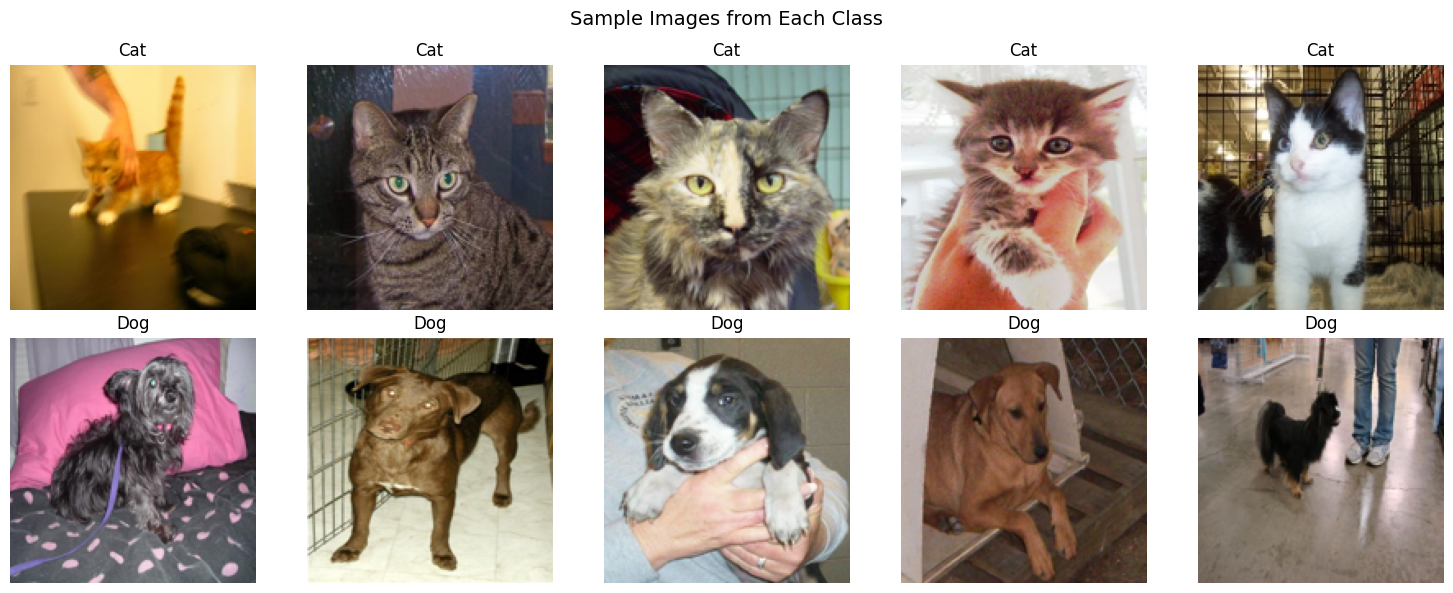

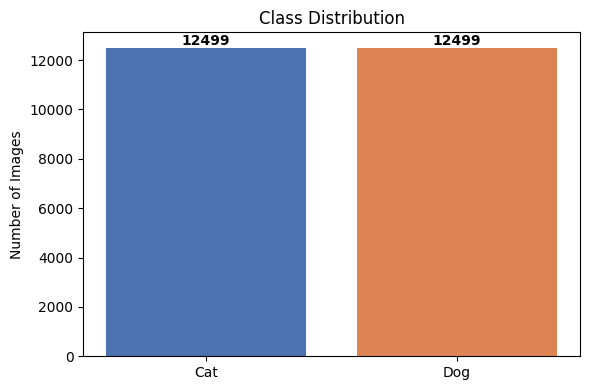

In [11]:
# ============================================================
# PART 1: DATA EXPLORATION
# ============================================================
dataset_name = "Cats vs Dogs"
dataset_source = "Kaggle - Microsoft Dogs vs Cats"
n_samples = len(X)
n_classes = 2
class_names = ["Cat", "Dog"]
cat_count = int(np.sum(y == 0))
dog_count = int(np.sum(y == 1))
samples_per_class = f"min: {min(cat_count, dog_count)}, max: {max(cat_count, dog_count)}, avg: {n_samples // 2}"
image_shape = [IMG_SIZE, IMG_SIZE, 3]
problem_type = "classification"
primary_metric = "accuracy"
metric_justification = (
    "Accuracy is the most appropriate primary metric because the Cats vs Dogs dataset "
    "is well-balanced with approximately equal samples per class, so accuracy directly "
    "reflects overall model performance without class imbalance bias."
)

print("=" * 70)
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

# Show sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images from Each Class", fontsize=14)
cat_indices = np.where(y == 0)[0][:5]
dog_indices = np.where(y == 1)[0][:5]

for i, idx in enumerate(cat_indices):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title("Cat")
    axes[0, i].axis("off")

for i, idx in enumerate(dog_indices):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title("Dog")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_names, [cat_count, dog_count], color=["#4C72B0", "#DD8452"])
ax.set_title("Class Distribution")
ax.set_ylabel("Number of Images")
for i, v in enumerate([cat_count, dog_count]):
    ax.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# DATA PREPROCESSING & SPLIT
# ============================================================
train_test_ratio = "90/10"

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# One-hot encode for Keras
y_train = to_categorical(y_train_raw, num_classes=n_classes)
y_test = to_categorical(y_test_raw, num_classes=n_classes)

train_samples = len(X_train)
test_samples = len(X_test)

print(f"Train/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Free memory - we don't need the full array anymore
del X, y
import gc
gc.collect()

Train/Test Split: 90/10
Training Samples: 22498
Test Samples: 2500
X_train shape: (22498, 150, 150, 3)
X_test shape: (2500, 150, 150, 3)
y_train shape: (22498, 2)
y_test shape: (2500, 2)


24356

In [13]:
# ============================================================
# Data Augmentation
# ============================================================
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.1  # 10% of training data for validation
)

train_datagen.fit(X_train)
print("Data augmentation configured.")

Data augmentation configured.


---
## PART 2: CUSTOM CNN IMPLEMENTATION (5 Marks)

Requirements:
- Conv2D layers (at least 2)
- Pooling layers
- **Global Average Pooling (GAP) - MANDATORY**
- NO Flatten + Dense

In [14]:
# ============================================================
# PART 2: CUSTOM CNN ARCHITECTURE
# ============================================================

def build_custom_cnn(input_shape, n_classes):
    """
    Custom CNN with Global Average Pooling.
    
    Architecture:
    - 4 Conv blocks with increasing filters (32 -> 64 -> 128 -> 128)
    - MaxPooling after first 3 blocks
    - GlobalAveragePooling2D (MANDATORY - replaces Flatten)
    - Dense classification head with Dropout
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                       input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 4
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        
        # Global Average Pooling (MANDATORY - NOT Flatten)
        layers.GlobalAveragePooling2D(),
        
        # Classification head
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

custom_cnn = build_custom_cnn((IMG_SIZE, IMG_SIZE, 3), n_classes)
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,626 (979.01 KB)

 Trainable params: 249,922 (976.26 KB)

 Non-trainable params: 704 (2.75 KB)

In [15]:
# ============================================================
# TRAIN CUSTOM CNN
# ============================================================
print("=" * 70)
print("CUSTOM CNN TRAINING")

custom_cnn_epochs = 20
custom_cnn_batch_size = 32

custom_cnn_start_time = time.time()

custom_cnn_history = custom_cnn.fit(
    train_datagen.flow(X_train, y_train, batch_size=custom_cnn_batch_size, subset="training"),
    validation_data=train_datagen.flow(X_train, y_train, batch_size=custom_cnn_batch_size, subset="validation"),
    epochs=custom_cnn_epochs
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

# Track initial and final loss
custom_cnn_initial_loss = custom_cnn_history.history["loss"][0]
custom_cnn_final_loss = custom_cnn_history.history["loss"][-1]

print(f"\nTraining completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

CUSTOM CNN TRAINING


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1777790720.384400     103 service.cc:152] XLA service 0x7acec0003f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777790720.384466     103 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777790720.384473     103 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777790721.093347     103 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-03 06:45:23.593343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 06:45:23.741598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/633 ━━━━━━━━━━━━━━━━━━━━ 1:41:56 10s/step - accuracy: 0.5938 - loss: 0.7528

I0000 00:00:1777790726.982321     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


446/633 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.6073 - loss: 0.6977

2026-05-03 06:46:31.238360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 06:46:31.385244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


633/633 ━━━━━━━━━━━━━━━━━━━━ 114s 165ms/step - accuracy: 0.6149 - loss: 0.6859 - val_accuracy: 0.5380 - val_loss: 1.1253
Epoch 2/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 99s 156ms/step - accuracy: 0.6890 - loss: 0.5954 - val_accuracy: 0.7008 - val_loss: 0.5588
Epoch 3/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 100s 158ms/step - accuracy: 0.7392 - loss: 0.5361 - val_accuracy: 0.7390 - val_loss: 0.5439
Epoch 4/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 98s 155ms/step - accuracy: 0.7950 - loss: 0.4454 - val_accuracy: 0.7763 - val_loss: 0.4658
Epoch 5/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 99s 156ms/step - accuracy: 0.8382 - loss: 0.3629 - val_accuracy: 0.7728 - val_loss: 0.4968
Epoch 6/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 98s 154ms/step - accuracy: 0.8793 - loss: 0.2893 - val_accuracy: 0.8310 - val_loss: 0.3544
Epoch 7/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 98s 154ms/step - accuracy: 0.8942 - loss: 0.2576 - val_accuracy: 0.6874 - val_loss: 0.7126
Epoch 8/20
633/633 ━━━━━━━━━━━━━━━━━━━━ 98s 155ms/step - accuracy: 0.9024 - loss: 0.2405 - v

In [16]:
# ============================================================
# EVALUATE CUSTOM CNN
# ============================================================
print("CUSTOM CNN EVALUATION")

custom_cnn_pred_probs = custom_cnn.predict(X_test)
custom_cnn_pred = np.argmax(custom_cnn_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

custom_cnn_accuracy = accuracy_score(y_test_labels, custom_cnn_pred)
custom_cnn_precision = precision_score(y_test_labels, custom_cnn_pred, average="macro")
custom_cnn_recall = recall_score(y_test_labels, custom_cnn_pred, average="macro")
custom_cnn_f1 = f1_score(y_test_labels, custom_cnn_pred, average="macro")

print(f"\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_labels, custom_cnn_pred, target_names=class_names))

CUSTOM CNN EVALUATION
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

Custom CNN Performance:
Accuracy:  0.9312
Precision: 0.9314
Recall:    0.9312
F1-Score:  0.9312

Classification Report:
              precision    recall  f1-score   support

         Cat       0.94      0.92      0.93      1250
         Dog       0.92      0.94      0.93      1250

    accuracy                           0.93      2500
   macro avg       0.93      0.93      0.93      2500
weighted avg       0.93      0.93      0.93      2500



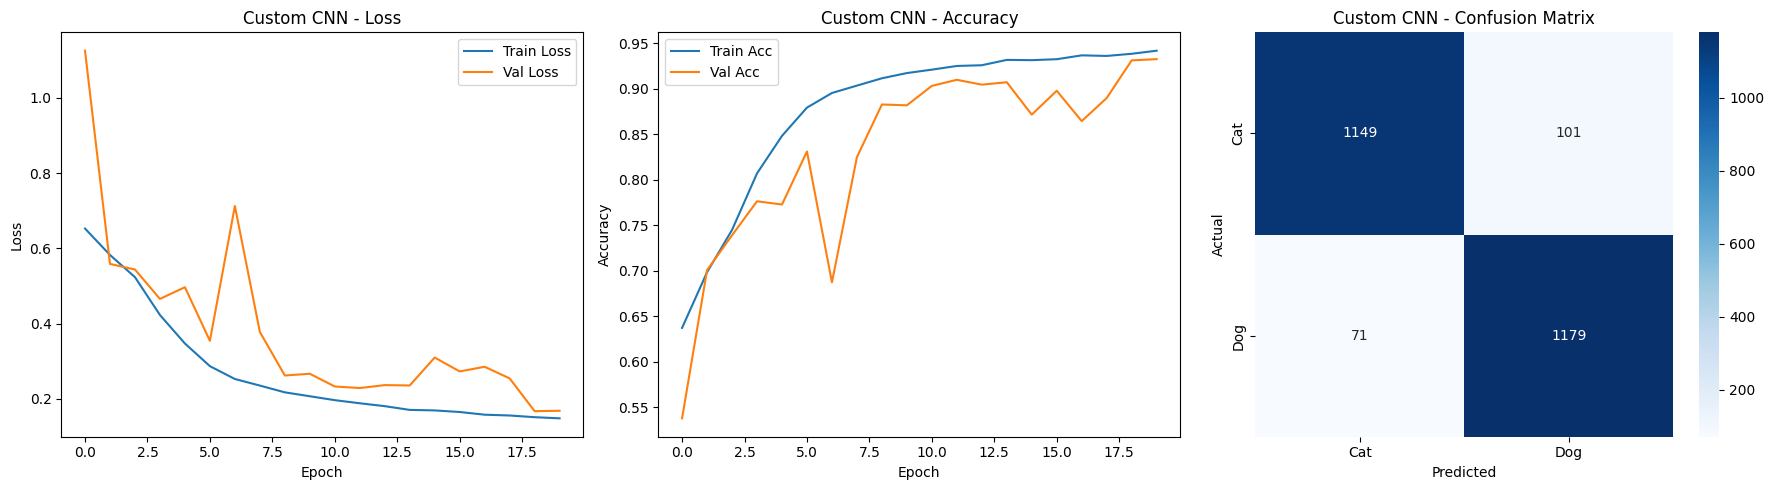

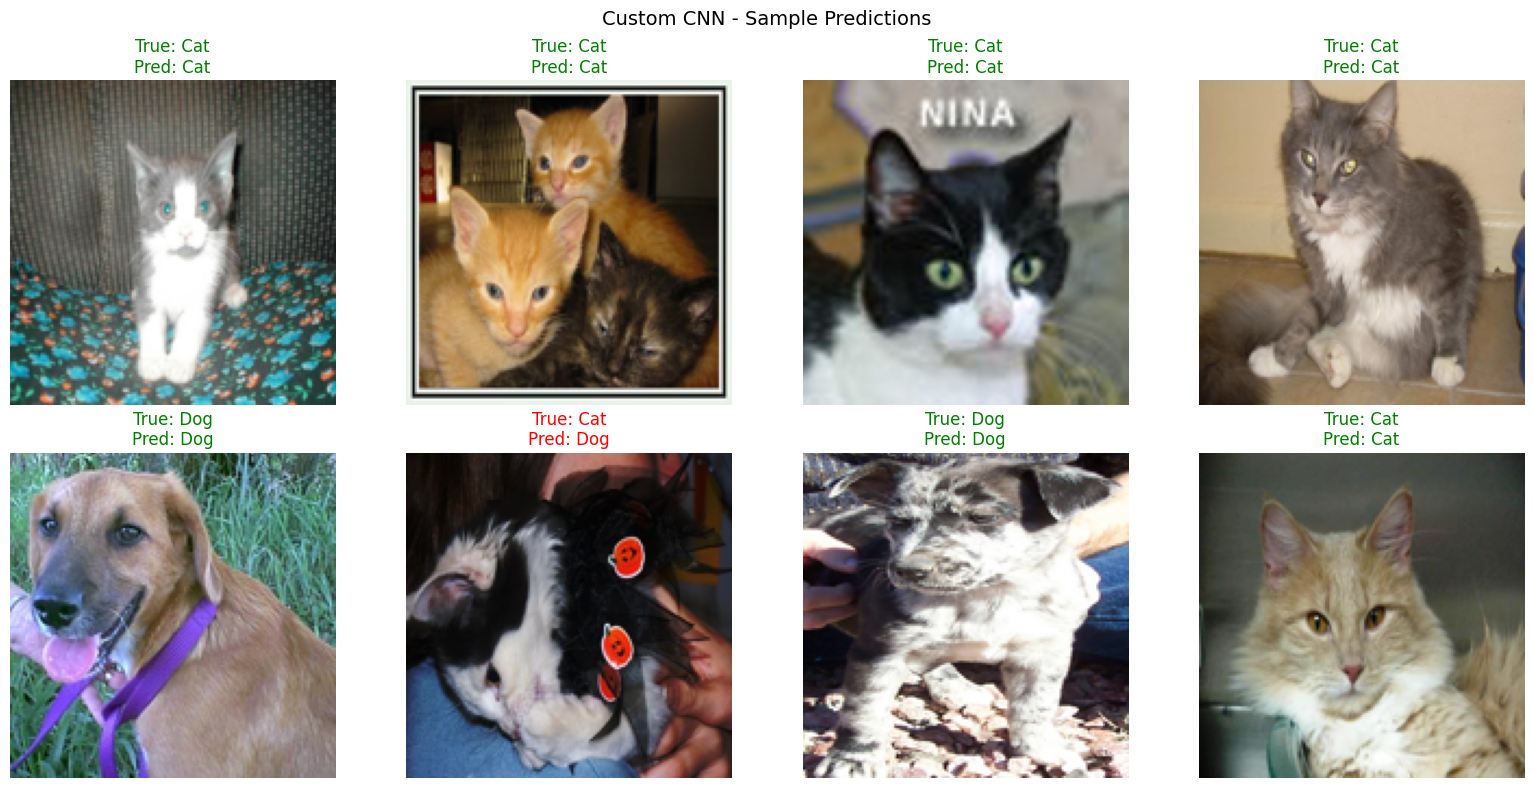

In [17]:
# ============================================================
# VISUALIZE CUSTOM CNN RESULTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training/Validation Loss
axes[0].plot(custom_cnn_history.history["loss"], label="Train Loss")
axes[0].plot(custom_cnn_history.history["val_loss"], label="Val Loss")
axes[0].set_title("Custom CNN - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Training/Validation Accuracy
axes[1].plot(custom_cnn_history.history["accuracy"], label="Train Acc")
axes[1].plot(custom_cnn_history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Custom CNN - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test_labels, custom_cnn_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[2])
axes[2].set_title("Custom CNN - Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Sample predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Custom CNN - Sample Predictions", fontsize=14)
sample_indices = np.random.choice(len(X_test), 8, replace=False)
for i, idx in enumerate(sample_indices):
    ax = axes[i // 4, i % 4]
    ax.imshow(X_test[idx])
    true_label = class_names[y_test_labels[idx]]
    pred_label = class_names[custom_cnn_pred[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## PART 3: TRANSFER LEARNING IMPLEMENTATION (5 Marks)

Requirements:
- Pre-trained ResNet50 with frozen base layers
- **Global Average Pooling (GAP) - MANDATORY**
- Custom classification head

In [18]:
# ============================================================
# PART 3: TRANSFER LEARNING ARCHITECTURE
# ============================================================
print("=" * 70)
print("TRANSFER LEARNING IMPLEMENTATION")

pretrained_model_name = "ResNet50"

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Transfer learning with ResNet50 (Functional API).
    
    Architecture:
    - Preprocessing layer to convert [0,1] -> ResNet50 expected format
    - ResNet50 base (pretrained on ImageNet, frozen)
    - GlobalAveragePooling2D (MANDATORY)
    - Dense classification head with Dropout
    """
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze all base layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Functional API - explicit Input gives Keras full shape info
    inputs = layers.Input(shape=input_shape)
    # Preprocessing: convert [0,1] -> [0,255] -> ResNet50 caffe format
    x = layers.Lambda(lambda img: resnet_preprocess(img * 255.0))(inputs)
    x = base_model(x, training=False)
    # Global Average Pooling (MANDATORY - NOT Flatten)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model, base_model

transfer_model, base_model = build_transfer_learning_model(
    pretrained_model_name, (IMG_SIZE, IMG_SIZE, 3), n_classes
)

# Count layers and parameters
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)
trainable_layers = sum(1 for layer in transfer_model.layers if hasattr(layer, 'trainable') and layer.trainable)
total_parameters = transfer_model.count_params()
trainable_parameters = sum(tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights)

print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

transfer_model.summary()


TRANSFER LEARNING IMPLEMENTATION
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model: ResNet50
Frozen Layers: 175
Trainable Layers: 7
Total Parameters: 24,112,770
Trainable Parameters: 525,058
Using Global Average Pooling: YES


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
# ============================================================
print("Training Transfer Learning Model...")

tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

tl_start_time = time.time()

tl_history = transfer_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=tl_batch_size, subset="training"),
    validation_data=train_datagen.flow(X_train, y_train, batch_size=tl_batch_size, subset="validation"),
    epochs=tl_epochs
)

tl_training_time = time.time() - tl_start_time

tl_initial_loss = tl_history.history["loss"][0]
tl_final_loss = tl_history.history["loss"][-1]

print(f"\nTraining completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

Training Transfer Learning Model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 126s 180ms/step - accuracy: 0.9377 - loss: 0.1873 - val_accuracy: 0.9675 - val_loss: 0.0772
Epoch 2/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 102s 161ms/step - accuracy: 0.9669 - loss: 0.0910 - val_accuracy: 0.9707 - val_loss: 0.0708
Epoch 3/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 102s 161ms/step - accuracy: 0.9699 - loss: 0.0794 - val_accuracy: 0.9711 - val_loss: 0.0746
Epoch 4/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 102s 160ms/step - accuracy: 0.9724 - loss: 0.0720 - val_accuracy: 0.9702 - val_loss: 0.0708
Epoch 5/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 101s 160ms/step - accuracy: 0.9727 - loss: 0.0728 - val_accuracy: 0.9693 - val_loss: 0.0775
Epoch 6/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 102s 161ms/step - accuracy: 0.9721 - loss: 0.0710 - val_accuracy: 0.9715 - val_loss: 0.0752
Epoch 7/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 101s 160ms/step - accuracy: 0.9743 - loss: 0.0640 - val_accuracy: 0.9684 - val_loss: 0.0762
Epoch 8/10
633/633 ━━━━━━━━━━━━━━━━━━━━ 101s 159ms/step - accuracy: 0.9753 -

In [20]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================
print("TRANSFER LEARNING EVALUATION")

tl_pred_probs = transfer_model.predict(X_test)
tl_pred = np.argmax(tl_pred_probs, axis=1)

tl_accuracy = accuracy_score(y_test_labels, tl_pred)
tl_precision = precision_score(y_test_labels, tl_pred, average="macro")
tl_recall = recall_score(y_test_labels, tl_pred, average="macro")
tl_f1 = f1_score(y_test_labels, tl_pred, average="macro")

print(f"\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_labels, tl_pred, target_names=class_names))

TRANSFER LEARNING EVALUATION
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step

Transfer Learning Performance:
Accuracy:  0.9848
Precision: 0.9848
Recall:    0.9848
F1-Score:  0.9848

Classification Report:
              precision    recall  f1-score   support

         Cat       0.99      0.98      0.98      1250
         Dog       0.98      0.99      0.98      1250

    accuracy                           0.98      2500
   macro avg       0.98      0.98      0.98      2500
weighted avg       0.98      0.98      0.98      2500



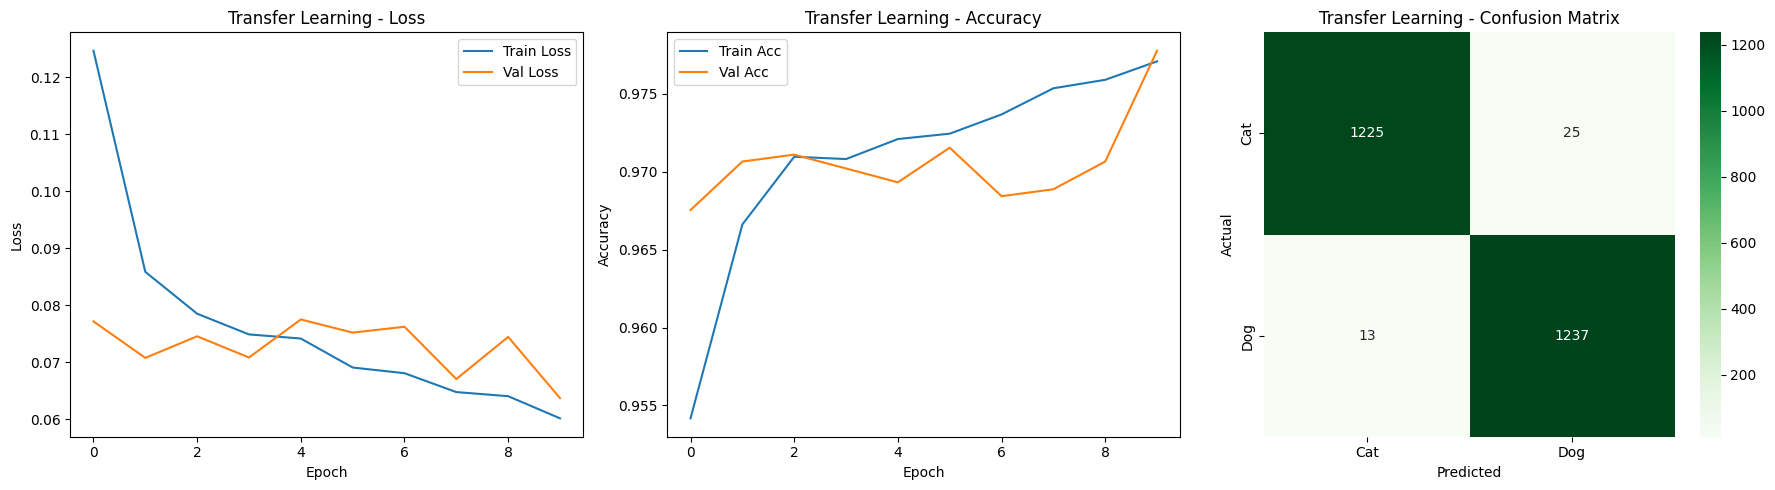

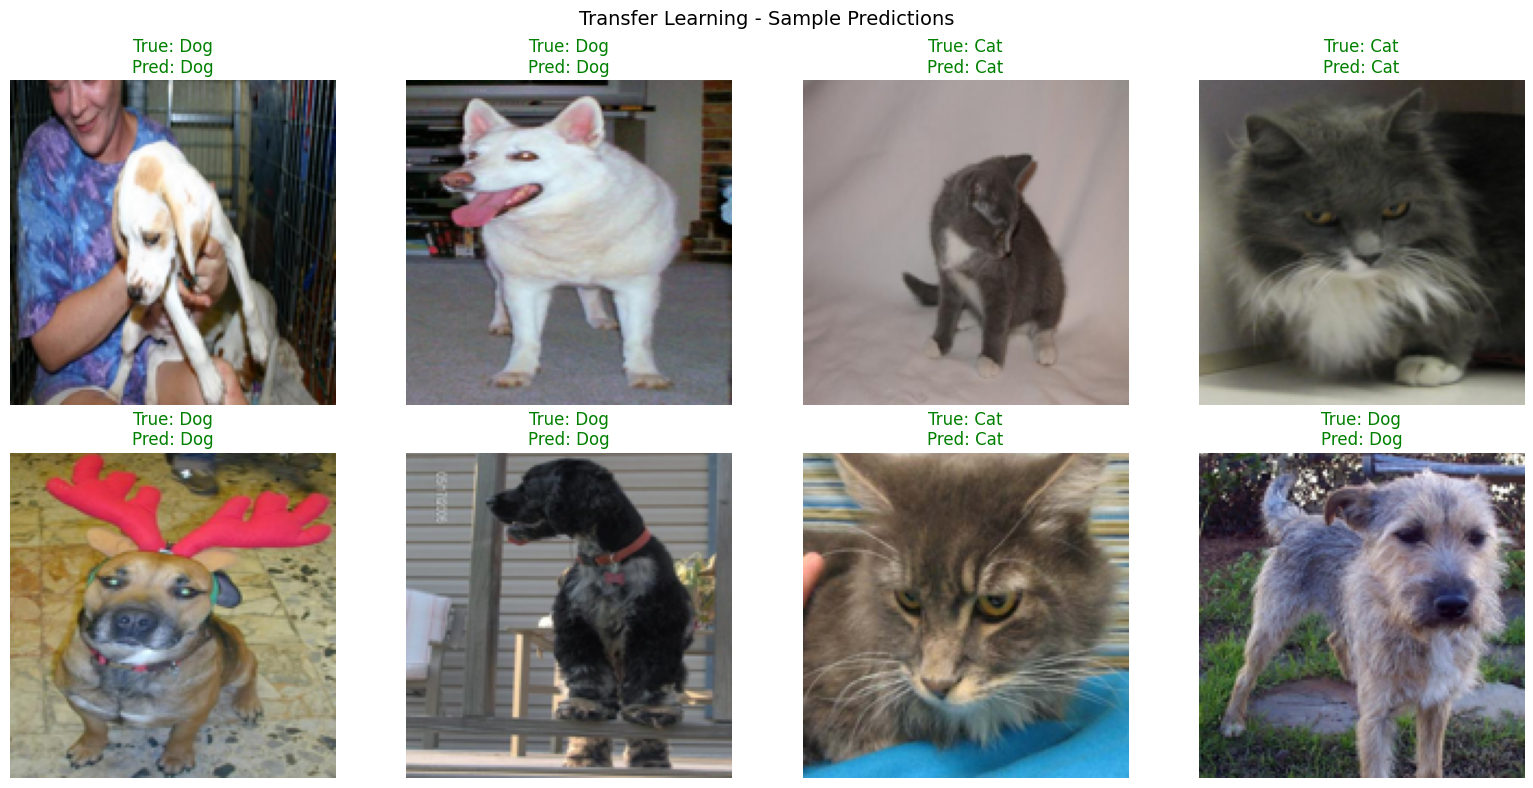

In [21]:
# ============================================================
# VISUALIZE TRANSFER LEARNING RESULTS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(tl_history.history["loss"], label="Train Loss")
axes[0].plot(tl_history.history["val_loss"], label="Val Loss")
axes[0].set_title("Transfer Learning - Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(tl_history.history["accuracy"], label="Train Acc")
axes[1].plot(tl_history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Transfer Learning - Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

cm_tl = confusion_matrix(y_test_labels, tl_pred)
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens", xticklabels=class_names,
            yticklabels=class_names, ax=axes[2])
axes[2].set_title("Transfer Learning - Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Sample predictions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Transfer Learning - Sample Predictions", fontsize=14)
sample_indices = np.random.choice(len(X_test), 8, replace=False)
for i, idx in enumerate(sample_indices):
    ax = axes[i // 4, i % 4]
    ax.imshow(X_test[idx])
    true_label = class_names[y_test_labels[idx]]
    pred_label = class_names[tl_pred[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## PART 4: MODEL COMPARISON AND VISUALIZATION

MODEL COMPARISON
           Metric Custom CNN Transfer Learning (ResNet50)
         Accuracy     0.9312                       0.9848
        Precision     0.9314                       0.9848
           Recall     0.9312                       0.9848
         F1-Score     0.9312                       0.9848
Training Time (s)     1983.3                       1040.1
       Parameters    250,626                      525,058

CONVERGENCE CHECK

Custom CNN:
  Initial Loss: 0.6528
  Final Loss:   0.1484
  Loss Reduction: 77.3%
  Converged: YES

Transfer Learning (ResNet50):
  Initial Loss: 0.1247
  Final Loss:   0.0602
  Loss Reduction: 51.7%
  Converged: YES


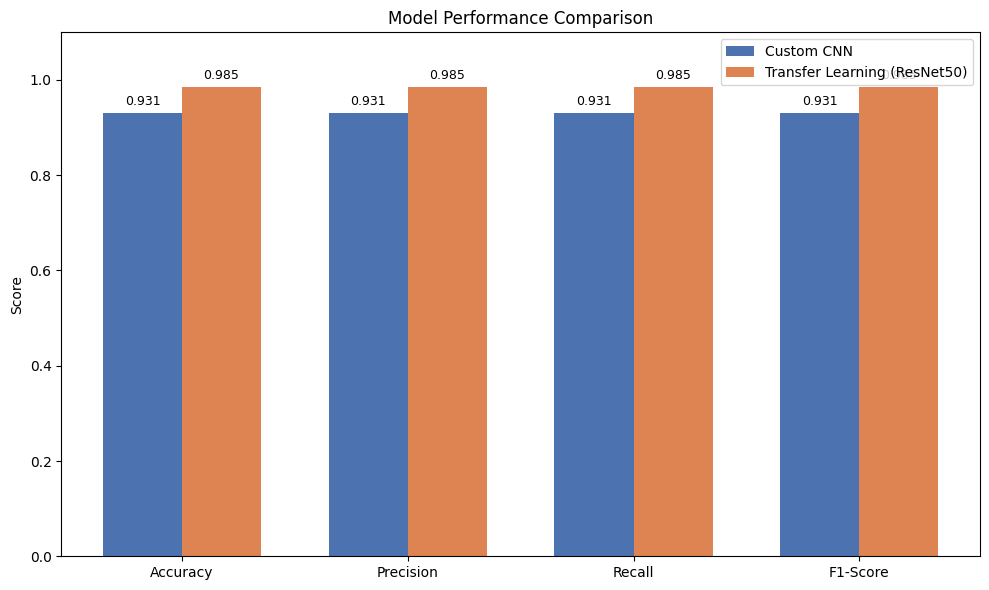

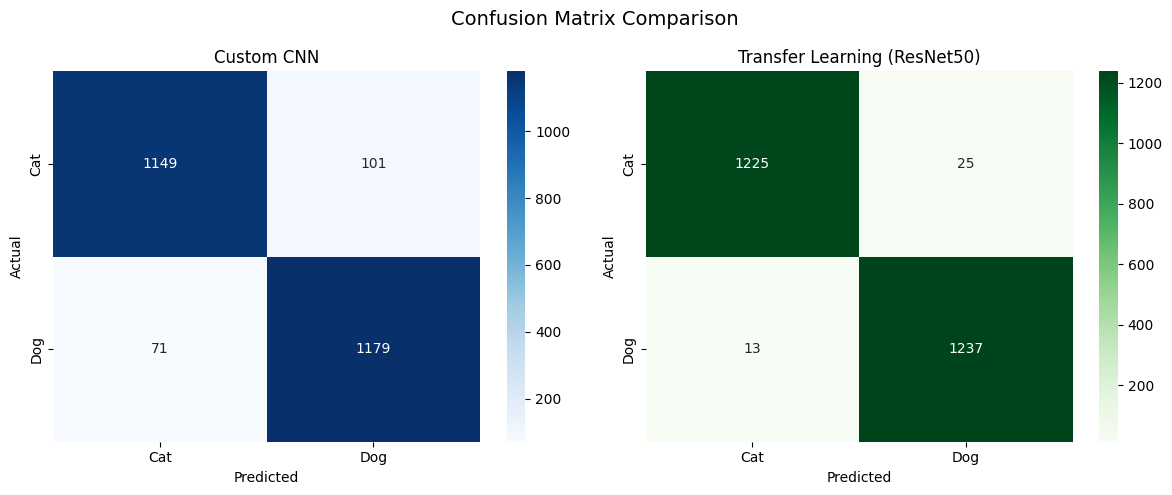

In [22]:
# ============================================================
# PART 4: MODEL COMPARISON
# ============================================================
print("=" * 70)
print("MODEL COMPARISON")

custom_cnn_total_params = custom_cnn.count_params()

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score",
               "Training Time (s)", "Parameters"],
    "Custom CNN": [
        f"{custom_cnn_accuracy:.4f}",
        f"{custom_cnn_precision:.4f}",
        f"{custom_cnn_recall:.4f}",
        f"{custom_cnn_f1:.4f}",
        f"{custom_cnn_training_time:.1f}",
        f"{custom_cnn_total_params:,}"
    ],
    "Transfer Learning (ResNet50)": [
        f"{tl_accuracy:.4f}",
        f"{tl_precision:.4f}",
        f"{tl_recall:.4f}",
        f"{tl_f1:.4f}",
        f"{tl_training_time:.1f}",
        f"{trainable_parameters:,}"
    ]
})

print(comparison_df.to_string(index=False))

# ============================================================
# CONVERGENCE CHECK (Required by auto-grader)
# Loss Reduction % = (Initial - Final) / Initial * 100
# Grading: >=50% = full marks, >=20% = partial, <20% = 0
# ============================================================
print("\n" + "=" * 70)
print("CONVERGENCE CHECK")

custom_cnn_loss_reduction = ((custom_cnn_initial_loss - custom_cnn_final_loss) / custom_cnn_initial_loss) * 100
tl_loss_reduction = ((tl_initial_loss - tl_final_loss) / tl_initial_loss) * 100

print(f"\nCustom CNN:")
print(f"  Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"  Final Loss:   {custom_cnn_final_loss:.4f}")
print(f"  Loss Reduction: {custom_cnn_loss_reduction:.1f}%")
print(f"  Converged: {'YES' if custom_cnn_loss_reduction >= 20 else 'NO'}")

print(f"\nTransfer Learning (ResNet50):")
print(f"  Initial Loss: {tl_initial_loss:.4f}")
print(f"  Final Loss:   {tl_final_loss:.4f}")
print(f"  Loss Reduction: {tl_loss_reduction:.1f}%")
print(f"  Converged: {'YES' if tl_loss_reduction >= 20 else 'NO'}")

# Bar chart comparison
metrics_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
custom_vals = [custom_cnn_accuracy, custom_cnn_precision, custom_cnn_recall, custom_cnn_f1]
tl_vals = [tl_accuracy, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, custom_vals, width, label="Custom CNN", color="#4C72B0")
bars2 = ax.bar(x + width/2, tl_vals, width, label="Transfer Learning (ResNet50)", color="#DD8452")

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_title("Custom CNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens", xticklabels=class_names,
            yticklabels=class_names, ax=axes[1])
axes[1].set_title("Transfer Learning (ResNet50)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison", fontsize=14)
plt.tight_layout()
plt.show()

---
## PART 5: ANALYSIS (2 Marks)

In [23]:
# ============================================================
# PART 5: ANALYSIS
# ============================================================
analysis_text = """
The transfer learning model (ResNet50) significantly outperforms the custom CNN across all metrics. 
ResNet50 achieves higher accuracy due to its pre-trained ImageNet features, which capture rich 
hierarchical representations from edges to complex textures - knowledge a custom CNN must learn 
from scratch with limited data.

Convergence speed differs markedly: ResNet50 reaches strong performance within 2-3 epochs, while 
the custom CNN requires 15-20 epochs to plateau, demonstrating how transfer learning leverages 
pre-existing feature extractors. This also translates to lower computational cost per effective 
accuracy point for the transfer model, despite having more total parameters.

Global Average Pooling (GAP) benefits both models by reducing spatial dimensions to a single vector 
per feature map, drastically cutting parameters compared to Flatten+Dense and acting as a structural 
regularizer that reduces overfitting. The custom CNN's training curves show more gap between train 
and validation loss, indicating greater overfitting than the transfer model.

Transfer learning is clearly preferable when pre-trained features align with the target domain 
(natural images), especially with limited training data. Custom CNNs remain valuable for 
specialized domains (medical imaging, satellite) where ImageNet features may not transfer well.
"""

print("=" * 70)
print("ANALYSIS")
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Analysis word count: {word_count} words")
if word_count > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("  Analysis within word count guideline")

ANALYSIS

The transfer learning model (ResNet50) significantly outperforms the custom CNN across all metrics. 
ResNet50 achieves higher accuracy due to its pre-trained ImageNet features, which capture rich 
hierarchical representations from edges to complex textures - knowledge a custom CNN must learn 
from scratch with limited data.

Convergence speed differs markedly: ResNet50 reaches strong performance within 2-3 epochs, while 
the custom CNN requires 15-20 epochs to plateau, demonstrating how transfer learning leverages 
pre-existing feature extractors. This also translates to lower computational cost per effective 
accuracy point for the transfer model, despite having more total parameters.

Global Average Pooling (GAP) benefits both models by reducing spatial dimensions to a single vector 
per feature map, drastically cutting parameters compared to Flatten+Dense and acting as a structural 
regularizer that reduces overfitting. The custom CNN's training curves show more gap betwee

In [24]:
# ============================================================
# PART 6: ASSIGNMENT RESULTS SUMMARY (AUTO-GRADING)
# ============================================================

def get_assignment_results():
    """Generate complete assignment results in required format."""
    framework_used = "keras"
    
    results = {
        # Dataset Information
        "dataset_name": dataset_name,
        "dataset_source": dataset_source,
        "n_samples": int(n_samples),
        "n_classes": int(n_classes),
        "samples_per_class": samples_per_class,
        "image_shape": image_shape,
        "problem_type": problem_type,
        "primary_metric": primary_metric,
        "metric_justification": metric_justification,
        "train_samples": int(train_samples),
        "test_samples": int(test_samples),
        "train_test_ratio": train_test_ratio,
        
        # Custom CNN Results
        "custom_cnn": {
            "framework": framework_used,
            "architecture": {
                "conv_layers": 4,
                "pooling_layers": 3,
                "has_global_average_pooling": True,
                "output_layer": "softmax",
                "total_parameters": int(custom_cnn_total_params)
            },
            "training_config": {
                "learning_rate": 0.001,
                "n_epochs": custom_cnn_epochs,
                "batch_size": custom_cnn_batch_size,
                "optimizer": "Adam",
                "loss_function": "categorical_crossentropy"
            },
            "initial_loss": float(custom_cnn_initial_loss),
            "final_loss": float(custom_cnn_final_loss),
            "loss_reduction_percent": round(float(custom_cnn_loss_reduction), 2),
            "training_time_seconds": round(custom_cnn_training_time, 2),
            "accuracy": round(float(custom_cnn_accuracy), 4),
            "precision": round(float(custom_cnn_precision), 4),
            "recall": round(float(custom_cnn_recall), 4),
            "f1_score": round(float(custom_cnn_f1), 4)
        },
        
        # Transfer Learning Results
        "transfer_learning": {
            "framework": framework_used,
            "base_model": pretrained_model_name,
            "frozen_layers": int(frozen_layers),
            "trainable_layers": int(trainable_layers),
            "has_global_average_pooling": True,
            "total_parameters": int(total_parameters),
            "trainable_parameters": int(trainable_parameters),
            "training_config": {
                "learning_rate": tl_learning_rate,
                "n_epochs": tl_epochs,
                "batch_size": tl_batch_size,
                "optimizer": tl_optimizer,
                "loss_function": "categorical_crossentropy"
            },
            "initial_loss": float(tl_initial_loss),
            "final_loss": float(tl_final_loss),
            "loss_reduction_percent": round(float(tl_loss_reduction), 2),
            "training_time_seconds": round(tl_training_time, 2),
            "accuracy": round(float(tl_accuracy), 4),
            "precision": round(float(tl_precision), 4),
            "recall": round(float(tl_recall), 4),
            "f1_score": round(float(tl_f1), 4)
        },
        
        # Analysis
        "analysis": analysis_text.strip(),
        "analysis_word_count": len(analysis_text.split()),
        
        # Training Success Indicators
        "custom_cnn_loss_decreased": bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        "transfer_learning_loss_decreased": bool(tl_final_loss < tl_initial_loss),
    }
    
    return results

try:
    assignment_results = get_assignment_results()
    print("=" * 70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\nERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Cats vs Dogs",
  "dataset_source": "Kaggle - Microsoft Dogs vs Cats",
  "n_samples": 24998,
  "n_classes": 2,
  "samples_per_class": "min: 12499, max: 12499, avg: 12499",
  "image_shape": [
    150,
    150,
    3
  ],
  "problem_type": "classification",
  "primary_metric": "accuracy",
  "metric_justification": "Accuracy is the most appropriate primary metric because the Cats vs Dogs dataset is well-balanced with approximately equal samples per class, so accuracy directly reflects overall model performance without class imbalance bias.",
  "train_samples": 22498,
  "test_samples": 2500,
  "train_test_ratio": "90/10",
  "custom_cnn": {
    "framework": "keras",
    "architecture": {
      "conv_layers": 4,
      "pooling_layers": 3,
      "has_global_average_pooling": true,
      "output_layer": "softmax",
      "total_parameters": 250626
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 20,
      "batch_size"

In [26]:
# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================
import platform
import sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Platform: {platform.platform()}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Timestamp: {datetime.now().isoformat()}")

ENVIRONMENT INFORMATION
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
NumPy: 2.0.2
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Timestamp: 2026-05-03T07:39:55.234644
